# Convert a Colour Image to Grayscale

This notebook shows a basic preprocessing step for lane detection: turning a colour road image into a single-channel grayscale image.

**What it does:**
1. Loads the colour image `image_lane_c.jpg` with OpenCV.
2. Converts it from OpenCV's default **BGR** channel order to **RGB** so it displays correctly.
3. Converts it to **grayscale** and compares both versions side by side.
4. Looks at the image shapes and pixel statistics.
5. Saves the result as `image_lane_g.jpg`.

**Why grayscale?** Many classic computer vision algorithms, such as Canny edge detection, work on pixel intensity alone. Going from 3 channels to 1 cuts the data by two-thirds and makes later processing simpler and faster.

## 1. Imports

- `cv2` (OpenCV): image I/O and colour conversion
- `matplotlib`: displaying images
- `numpy`: array statistics
- `pathlib`: file paths that work on any OS

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Configuration

The input image is in the same folder as this notebook. The grayscale output is saved next to it.

In [2]:
INPUT_PATH = Path("image_lane_c.jpg")
OUTPUT_PATH = INPUT_PATH.with_name("image_lane_g.jpg")

## 3. Load the image

`cv2.imread` does **not** raise an error when a file is missing. It returns `None` instead, so we check for that explicitly.

> ⚠️ OpenCV loads images in **BGR** order, while Matplotlib expects **RGB**. We convert right away so the colours display correctly.

In [3]:
image_bgr = cv2.imread(str(INPUT_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_PATH.resolve()}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

height, width, channels = image_rgb.shape
print(f"Colour image: {width}x{height} px, {channels} channels, dtype={image_rgb.dtype}")

Colour image: 960x540 px, 3 channels, dtype=uint8


## 4. Convert to grayscale

OpenCV computes a weighted sum of the colour channels (ITU-R BT.601):

$$Y = 0.299\,R + 0.587\,G + 0.114\,B$$

Green gets the highest weight because the human eye is most sensitive to it.

In [4]:
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Grayscale image: shape={image_gray.shape}, dtype={image_gray.dtype}")

Grayscale image: shape=(540, 960), dtype=uint8


## 5. Compare the images side by side

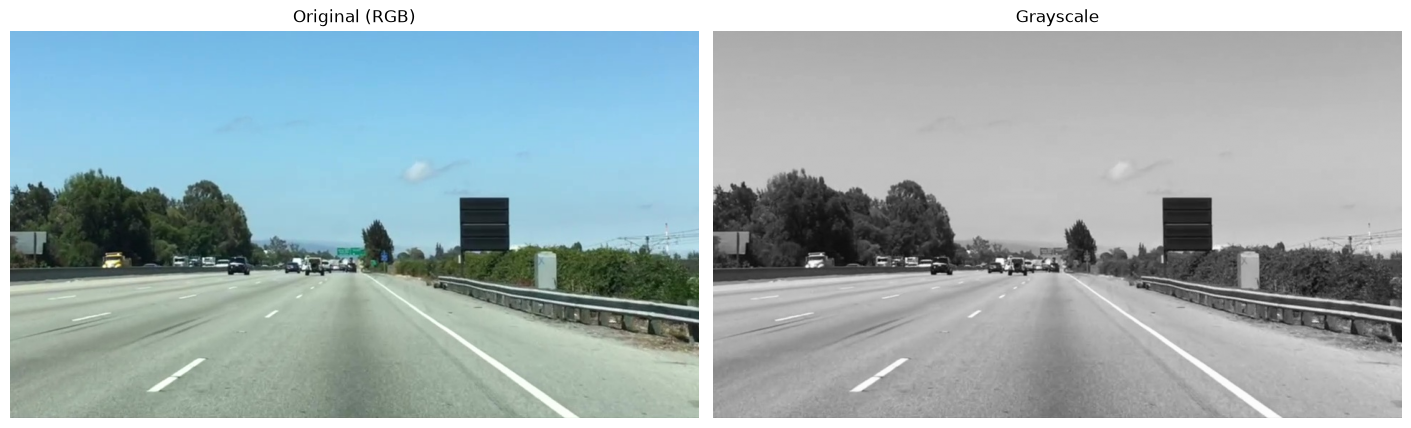

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

axes[0].imshow(image_rgb)
axes[0].set_title("Original (RGB)")

axes[1].imshow(image_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Grayscale")

for ax in axes:
    ax.axis("off")

plt.show()

## 6. Inspect the pixel values

The grayscale image is a 2D `uint8` array. Each value is a brightness level from **0 (black)** to **255 (white)**.

Printing the full array would produce hundreds of thousands of numbers, so we look at summary statistics and a small patch instead.

In [6]:
print(f"Min: {image_gray.min()}, Max: {image_gray.max()}, Mean: {image_gray.mean():.1f}")

# A 5x5 patch from the centre of the image
cy, cx = height // 2, width // 2
print("\nCentre patch (5x5):")
print(image_gray[cy - 2 : cy + 3, cx - 2 : cx + 3])

Min: 6, Max: 254, Mean: 161.4

Centre patch (5x5):
[[193 193 193 193 193]
 [193 193 193 193 193]
 [193 193 193 193 193]
 [192 192 193 193 193]
 [193 192 192 192 192]]


## 7. Save the grayscale image

`cv2.imwrite` returns `False` when saving fails, so we check the result.

In [7]:
if not cv2.imwrite(str(OUTPUT_PATH), image_gray):
    raise OSError(f"Could not write image: {OUTPUT_PATH.resolve()}")

print(f"Saved grayscale image to {OUTPUT_PATH.resolve()}")

Saved grayscale image to /workspaces/ml-autonomous-systems/convert_image_to_rgb/image_lane_g.jpg
